In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Loading the cleaned dataset

In [105]:
df=pd.read_csv(r"C:\Users\vidhi\OneDrive\Desktop\coding\Decodelab\data\cleaned_ecommerce_transactions.xls")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,No Coupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [106]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 2. Basic overview of the cleaned data

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [108]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


### Insight:
#### -The dataset contains transaction-level data with no missing values and consistent data types.
#### -The average quantity per order is around 3 items, and the average transaction value is ~1053.
#### -The presence of higher maximum values indicates some high-value transactions.

## 3. Calculating some key statistics

In [109]:
df['Quantity'].mean().round(2)

2.95

In [110]:
df['UnitPrice'].mean().round(2)

356.41

In [111]:
df['TotalPrice'].mean().round(2)

1053.97

In [112]:
df['TotalPrice'].median()

823.615

In [113]:
df['TotalPrice'].max()

3456.4

In [114]:
df['TotalPrice'].min()

11.39

## 4. Check distribution of sales

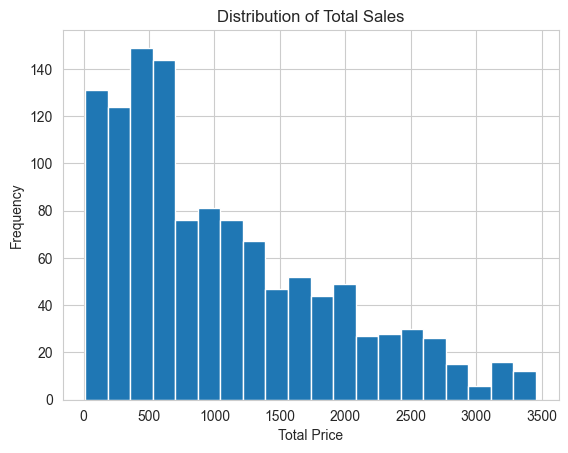

In [115]:
df['TotalPrice'].hist(bins=20)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

### Insight:
#### -The distribution of TotalPrice is right-skewed, meaning most transactions are of lower value, while a few transactions contribute significantly higher amounts.

## 1.2 Convert to date

In [116]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

## 5. Sales trend over time

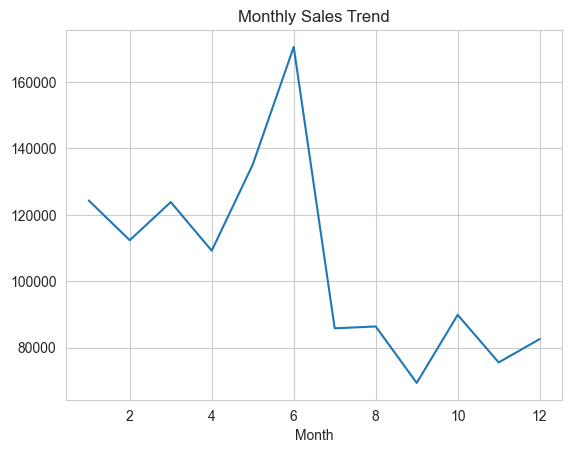

In [117]:
df.groupby('Month')['TotalPrice'].sum().plot()
plt.title('Monthly Sales Trend')
plt.show()

## Insight:
#### -Growth phase: Months 1–6 show steady improvement
#### -Best month: Month 6 (clear spike in revenue)
#### -Sudden decline: Big drop right after the peak (Month 7)
#### -Unstable period: Months 7–12 are inconsistent and weaker

## 6. Top Products

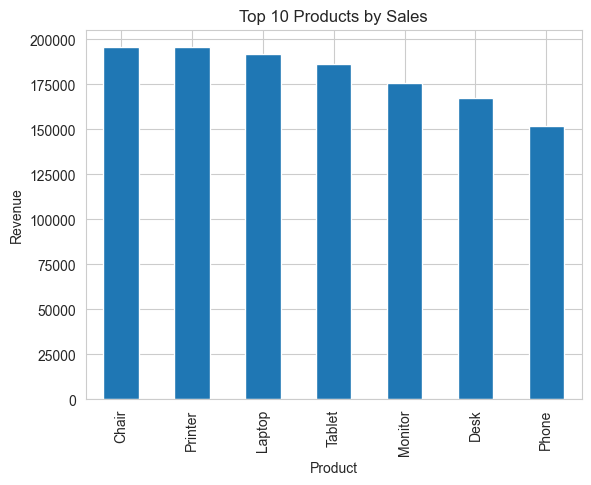

In [118]:
top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.ylabel("Revenue")
plt.show()

### Insight:
#### -A small number of products contribute a large portion of total revenue, suggesting that demand is concentrated among top-performing products.

## 7. Payment method analysis

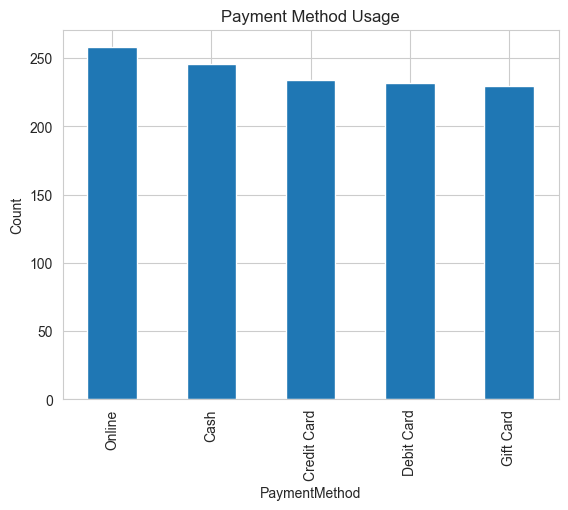

In [119]:
df['PaymentMethod'].value_counts().plot(kind='bar')
plt.title("Payment Method Usage")
plt.ylabel("Count")
plt.show()

### Insight:
#### -One or two payment methods dominate usage, indicating customer preference for specific transaction methods.

## 8.Customer Analysis

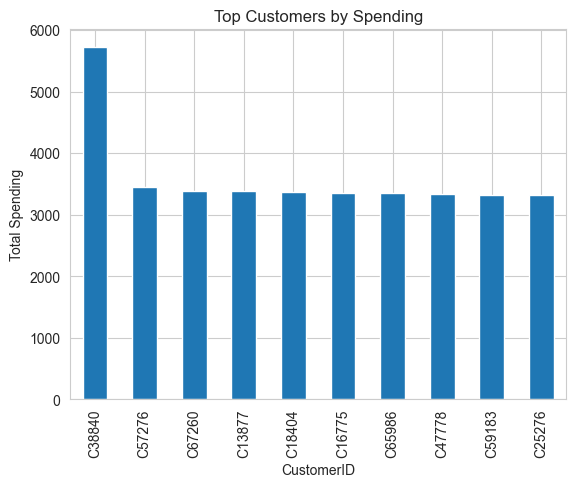

In [120]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

top_customers.head(10).plot(kind='bar')
plt.title("Top Customers by Spending")
plt.ylabel("Total Spending")
plt.show()

### Insight:
#### -A small group of customers contributes significantly to overall revenue, indicating the presence of high-value or repeat customers.
#### -C38840 has the highest spending out of all customers

## 9. Coupon usage

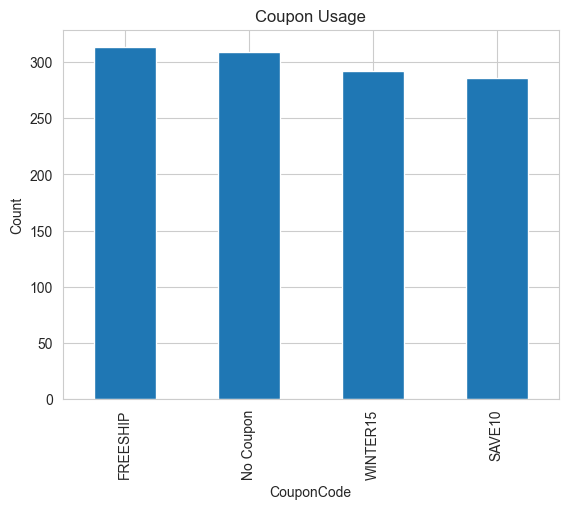

In [121]:
df['CouponCode'].value_counts().plot(kind='bar')
plt.title("Coupon Usage")
plt.ylabel("Count")
plt.show()

### Insight:
#### -A large portion of transactions occur without coupons, while a smaller segment of customers actively use discount codes.

## 10. Outlier detection

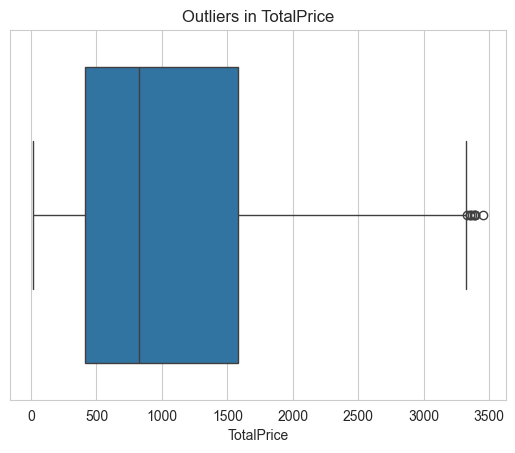

In [122]:
sns.boxplot(x=df['TotalPrice'])
plt.title("Outliers in TotalPrice")
plt.show()

### Insight:
#### -There are several high-value outliers in TotalPrice, indicating occasional large purchases that significantly impact total revenue.

## 11.Correlation Analysis

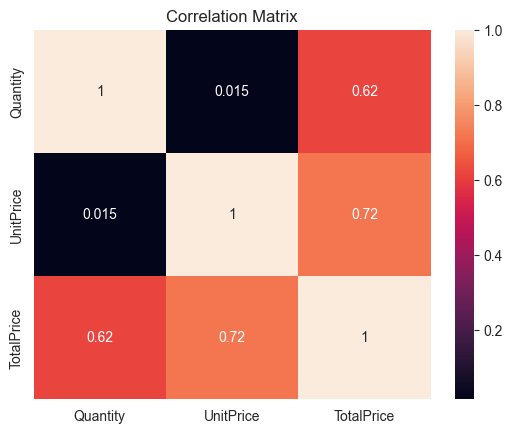

In [123]:
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

### Insight:
#### -TotalPrice shows strong positive correlation with Quantity and UnitPrice, confirming that total transaction value is directly influenced by both factors.

# Final Insights:

## 1. Most transactions involve 2–4 items, indicating typical purchasing behavior.
## 2. The sales trend shows a clear seasonal pattern: revenue builds steadily in the first half of the year, peaks sharply in Month 6, and then drops significantly and remains relatively low and unstable for the rest of the year.
## 3. A small number of products dominate total sales, showing uneven product demand.
## 4. Customer spending is concentrated among a few high-value customers.
## 5. Coupon usage is limited, with most customers not using discount codes.
## 6. Strong correlation exists between Quantity, UnitPrice, and TotalPrice.
## 7. Presence of outliers suggests occasional large purchases impacting overall revenue.
## 8.Your business appears to have a strong mid-year peak followed by a slowdown, suggesting seasonality or a one-time boost in Month 6.